In [1]:
import os
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import LogisticRegression
from xgboost                 import XGBClassifier
from lightgbm                import LGBMClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay,
    roc_curve,          
    accuracy_score,     
    precision_score,    
    recall_score,       
    f1_score            
)
import joblib

print("Imports OK !")

Imports OK !


In [2]:
# Constantes

FEATURE_NAMES = [
    "diagonal",
    "height_left",
    "height_right",
    "margin_low",
    "margin_up",
    "length"
]

TARGET_NAME = "is_genuine"   # 1 = Authentique | 0 = Faux

# Adapte ce chemin si nécessaire
DATA_PATH = r"C:\Users\HP\Desktop\fake-bill-detector\data\billets.csv"

# Dossier où on sauvegardera les modèles entraînés
MODELS_DIR = r"C:\Users\HP\Desktop\fake-bill-detector\models"

print("Constantes définies !") 

Constantes définies !


In [3]:
# Reproduction du preprocessing 

# Étape 1 : chargement
df = pd.read_csv(DATA_PATH, sep=";")

# Étape 3 : nettoyage des 37 valeurs manquantes dans margin_low on remplace par la moyenne de chaque classe

df_propre = df.copy()
moyenne_par_classe = df_propre.groupby(TARGET_NAME)["margin_low"].transform("mean")
df_propre["margin_low"] = df_propre["margin_low"].fillna(moyenne_par_classe)

# Étape 4 : encodage  True → 1  |  False → 0
df_propre[TARGET_NAME] = df_propre[TARGET_NAME].astype(int)

# Étape 5 : séparation X / y
X = df_propre[FEATURE_NAMES]
y = df_propre[TARGET_NAME]

# Étape 5 : split train / test  (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Étape 5 : normalisation
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Résumé
print("=" * 45)
print("  DONNÉES PRÊTES")
print("=" * 45)
print(f"  X_train_scaled : {X_train_scaled.shape}")
print(f"  X_test_scaled  : {X_test_scaled.shape}")
print(f"  y_train        : {y_train.shape}")
print(f"  y_test         : {y_test.shape}")
print("=" * 45)
print()
print("Distribution y_train :")
print(f"  1 (Authentique) : {(y_train == 1).sum()}")
print(f"  0 (Faux billet) : {(y_train == 0).sum()}") 

  DONNÉES PRÊTES
  X_train_scaled : (1200, 6)
  X_test_scaled  : (300, 6)
  y_train        : (1200,)
  y_test         : (300,)

Distribution y_train :
  1 (Authentique) : 800
  0 (Faux billet) : 400


In [4]:
# 1.1 Création du modèle 

modele_lr = LogisticRegression(max_iter=1000, random_state=42)

print("Modèle Régression Logistique créé.")
print(modele_lr) 

Modèle Régression Logistique créé.
LogisticRegression(max_iter=1000, random_state=42)


In [5]:
#  1.2 Entraînement 

modele_lr.fit(X_train_scaled, y_train)

print("Entraînement terminé !") 

Entraînement terminé !


In [6]:
# 1.3 Prédictions 

y_pred_lr  = modele_lr.predict(X_test_scaled)
y_proba_lr = modele_lr.predict_proba(X_test_scaled)[:, 1]

print("Prédictions effectuées.")
print(f"Exemple — 5 premières prédictions : {y_pred_lr[:5]}")
print(f"Exemple — 5 premières probabilités : {y_proba_lr[:5].round(3)}") 

Prédictions effectuées.
Exemple — 5 premières prédictions : [1 0 0 1 1]
Exemple — 5 premières probabilités : [0.999 0.    0.    0.618 0.998]


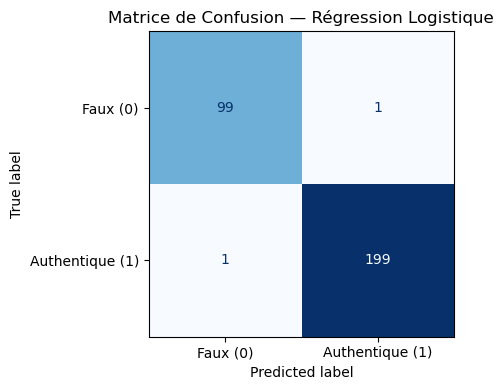

  TN (faux bien détectés)         : 99
  TP (vrais bien identifiés)       : 199
  FP (vrais classés comme faux)    : 1
  FN (faux passés inaperçus) ⚠️   : 1


In [7]:
# 1.4 Matrice de confusion 

cm_lr = confusion_matrix(y_test, y_pred_lr)

# Affichage graphique de la matrice
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                               display_labels=["Faux (0)", "Authentique (1)"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Matrice de Confusion — Régression Logistique", fontsize=12)
plt.tight_layout()
plt.show()

# Affichage des valeurs brutes
tn, fp, fn, tp = cm_lr.ravel()
print(f"  TN (faux bien détectés)         : {tn}")
print(f"  TP (vrais bien identifiés)       : {tp}")
print(f"  FP (vrais classés comme faux)    : {fp}")
print(f"  FN (faux passés inaperçus) ⚠️   : {fn}") 

In [8]:
# 1.5 Classification Report 

print("Classification Report — Régression Logistique")
print("=" * 50)
print(classification_report(y_test, y_pred_lr,
                             target_names=["Faux (0)", "Authentique (1)"])) 

Classification Report — Régression Logistique
                 precision    recall  f1-score   support

       Faux (0)       0.99      0.99      0.99       100
Authentique (1)       0.99      0.99      0.99       200

       accuracy                           0.99       300
      macro avg       0.99      0.99      0.99       300
   weighted avg       0.99      0.99      0.99       300



In [9]:
# 1.6 Score AUC-ROC 
auc_lr = roc_auc_score(y_test, y_proba_lr)

print("=" * 45)
print("  RÉSULTATS — Régression Logistique")
print("=" * 45)
print(f"  AUC-ROC : {auc_lr:.4f}")
print("=" * 45)

if auc_lr >= 0.9:
    print("  Interprétation : Excellent ✅")
elif auc_lr >= 0.8:
    print("  Interprétation : Bon 👍")
else:
    print("  Interprétation : A améliorer ⚠️") 

  RÉSULTATS — Régression Logistique
  AUC-ROC : 0.9996
  Interprétation : Excellent ✅


In [10]:
#  2.1 Création du modèle 
modele_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42
)

print("Modèle XGBoost créé.")
print(modele_xgb) 

Modèle XGBoost créé.
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)


In [11]:
# 2.2 Entraînement 
modele_xgb.fit(X_train_scaled, y_train)

print("Entraînement terminé !") 

Entraînement terminé !


In [12]:
#  2.3 Prédictions 
y_pred_xgb  = modele_xgb.predict(X_test_scaled)
y_proba_xgb = modele_xgb.predict_proba(X_test_scaled)[:, 1]

print("Prédictions effectuées.")
print(f"Exemple — 5 premières prédictions  : {y_pred_xgb[:5]}")
print(f"Exemple — 5 premières probabilités : {y_proba_xgb[:5].round(3)}") 

Prédictions effectuées.
Exemple — 5 premières prédictions  : [1 0 0 1 1]
Exemple — 5 premières probabilités : [0.999 0.001 0.001 0.974 0.997]


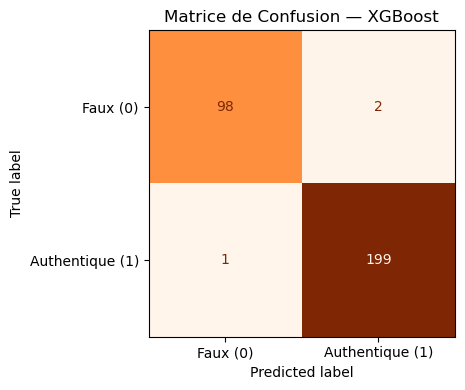

  TN (faux bien détectés)       : 98
  TP (vrais bien identifiés)     : 199
  FP (vrais classés comme faux)  : 2
  FN (faux passés inaperçus) ⚠️ : 1


In [13]:
#  2.4 Matrice de confusion 
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb,
                               display_labels=["Faux (0)", "Authentique (1)"])
disp.plot(ax=ax, colorbar=False, cmap="Oranges")
ax.set_title("Matrice de Confusion — XGBoost", fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_xgb.ravel()
print(f"  TN (faux bien détectés)       : {tn}")
print(f"  TP (vrais bien identifiés)     : {tp}")
print(f"  FP (vrais classés comme faux)  : {fp}")
print(f"  FN (faux passés inaperçus) ⚠️ : {fn}") 

In [14]:
# 2.5 Classification Report 

print("Classification Report — XGBoost")
print("=" * 50)
print(classification_report(y_test, y_pred_xgb,
                             target_names=["Faux (0)", "Authentique (1)"])) 

Classification Report — XGBoost
                 precision    recall  f1-score   support

       Faux (0)       0.99      0.98      0.98       100
Authentique (1)       0.99      0.99      0.99       200

       accuracy                           0.99       300
      macro avg       0.99      0.99      0.99       300
   weighted avg       0.99      0.99      0.99       300



In [15]:
#  2.6 Score AUC-ROC 

auc_xgb = roc_auc_score(y_test, y_proba_xgb)

print("=" * 45)
print("  RÉSULTATS — XGBoost")
print("=" * 45)
print(f"  AUC-ROC : {auc_xgb:.4f}")
print("=" * 45)
if auc_xgb >= 0.9:
    print("  Interprétation : Excellent ✅")
elif auc_xgb >= 0.8:
    print("  Interprétation : Bon 👍")
else:
    print("  Interprétation : A améliorer ⚠️")

print()
print("Comparaison rapide :")
print(f"  Régression Logistique : {auc_lr:.4f}")
print(f"  XGBoost               : {auc_xgb:.4f}") 

  RÉSULTATS — XGBoost
  AUC-ROC : 0.9992
  Interprétation : Excellent ✅

Comparaison rapide :
  Régression Logistique : 0.9996
  XGBoost               : 0.9992


In [16]:
import warnings
warnings.filterwarnings("ignore")

modele_lgbm = LGBMClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    verbose=-1,
    n_jobs=1,        
    random_state=42
)

print("Modèle LightGBM créé.")
print(modele_lgbm) 

Modèle LightGBM créé.
LGBMClassifier(max_depth=4, n_jobs=1, random_state=42, verbose=-1)


In [17]:
# 3.2 Entraînement 
modele_lgbm.fit(X_train_scaled, y_train)

print("Entraînement terminé !") 

Entraînement terminé !


In [18]:
#  3.3 Prédictions 
y_pred_lgbm  = modele_lgbm.predict(X_test_scaled)
y_proba_lgbm = modele_lgbm.predict_proba(X_test_scaled)[:, 1]

print("Prédictions effectuées.") 
print(f"Exemple — 5 premières prédictions  : {y_pred_lgbm[:5]}")
print(f"Exemple — 5 premières probabilités : {y_proba_lgbm[:5].round(3)}") 

Prédictions effectuées.
Exemple — 5 premières prédictions  : [1 0 0 1 1]
Exemple — 5 premières probabilités : [1.    0.    0.    0.993 1.   ]


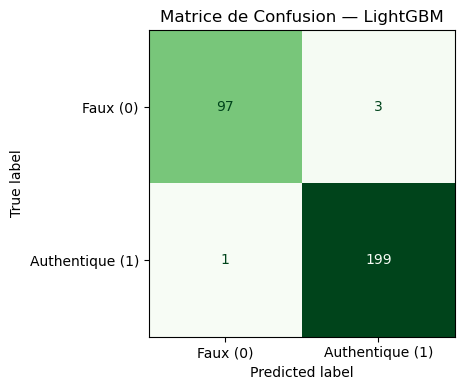

  TN (faux bien détectés)       : 97
  TP (vrais bien identifiés)     : 199
  FP (vrais classés comme faux)  : 3
  FN (faux passés inaperçus) ⚠️ : 1


In [19]:
#  3.4 Matrice de confusion 
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=cm_lgbm,
    display_labels=["Faux (0)", "Authentique (1)"]
).plot(ax=ax, colorbar=False, cmap="Greens")
ax.set_title("Matrice de Confusion — LightGBM", fontsize=12)
plt.tight_layout()
plt.show() 

tn, fp, fn, tp = cm_lgbm.ravel()
print(f"  TN (faux bien détectés)       : {tn}")
print(f"  TP (vrais bien identifiés)     : {tp}")
print(f"  FP (vrais classés comme faux)  : {fp}")
print(f"  FN (faux passés inaperçus) ⚠️ : {fn}") 

In [20]:
# 3.5 Classification Report 
print("Classification Report — LightGBM")
print("=" * 50)
print(classification_report(
    y_test, y_pred_lgbm,
    target_names=["Faux (0)", "Authentique (1)"]
)) 

Classification Report — LightGBM
                 precision    recall  f1-score   support

       Faux (0)       0.99      0.97      0.98       100
Authentique (1)       0.99      0.99      0.99       200

       accuracy                           0.99       300
      macro avg       0.99      0.98      0.98       300
   weighted avg       0.99      0.99      0.99       300



In [21]:
# 3.6 Score AUC-ROC 

auc_lgbm = roc_auc_score(y_test, y_proba_lgbm)

print("=" * 45)
print("  RÉSULTATS — LightGBM")
print("=" * 45)
print(f"  AUC-ROC : {auc_lgbm:.4f}")
print("=" * 45)
if auc_lgbm >= 0.9:
    print("  Interprétation : Excellent ✅")
elif auc_lgbm >= 0.8:
    print("  Interprétation : Bon 👍")
else:
    print("  Interprétation : A améliorer ⚠️")

print()
print("Comparaison des 3 modèles jusqu'ici :")
print("-" * 40)
print(f"  Régression Logistique : {auc_lr:.4f}")
print(f"  XGBoost               : {auc_xgb:.4f}")
print(f"  LightGBM              : {auc_lgbm:.4f}")
print("-" * 40) 

  RÉSULTATS — LightGBM
  AUC-ROC : 0.9994
  Interprétation : Excellent ✅

Comparaison des 3 modèles jusqu'ici :
----------------------------------------
  Régression Logistique : 0.9996
  XGBoost               : 0.9992
  LightGBM              : 0.9994
----------------------------------------


In [22]:
# ── 4.1 Tableau récapitulatif 

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calcul des métriques pour chaque modèle
resultats = {
    "Modèle": [
        "Régression Logistique",
        "XGBoost",
        "LightGBM"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lgbm)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_lgbm)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_lgbm)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_lgbm)
    ],
    "AUC-ROC": [
        auc_lr,
        auc_xgb,
        auc_lgbm
    ]
}

# Création du tableau
df_resultats = pd.DataFrame(resultats)

# On arrondit à 4 décimales pour la lisibilité
df_resultats[["Accuracy","Precision","Recall","F1-Score","AUC-ROC"]] = \
    df_resultats[["Accuracy","Precision","Recall","F1-Score","AUC-ROC"]].round(4)

print("Tableau comparatif des 3 modèles :")
print("=" * 75)
print(df_resultats.to_string(index=False))
print("=" * 75) 

Tableau comparatif des 3 modèles :
               Modèle  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Régression Logistique    0.9933     0.9950   0.995    0.9950   0.9996
              XGBoost    0.9900     0.9900   0.995    0.9925   0.9992
             LightGBM    0.9867     0.9851   0.995    0.9900   0.9994


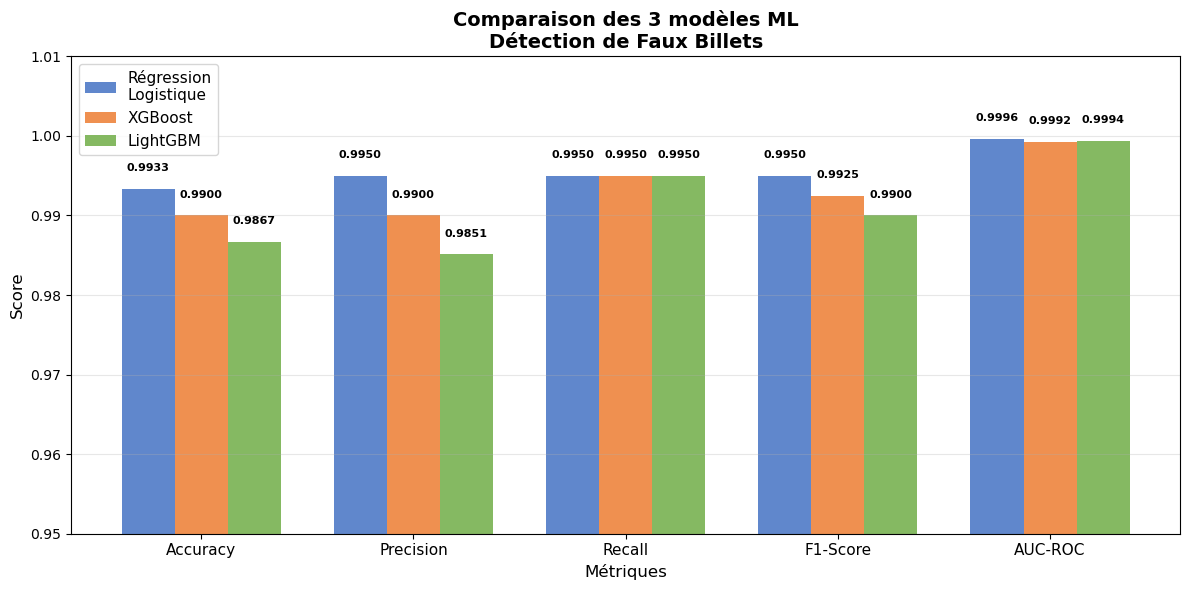

In [23]:
# 4.2 Graphique en barres 

metriques  = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]
modeles    = ["Régression\nLogistique", "XGBoost", "LightGBM"]
couleurs   = ["#4472C4", "#ED7D31", "#70AD47"]

x     = np.arange(len(metriques))   # position des groupes sur l'axe X
width = 0.25                        # largeur de chaque barre

fig, ax = plt.subplots(figsize=(12, 6))

# On trace une barre par modèle, décalée sur l'axe X
for i, (modele, couleur) in enumerate(zip(modeles, couleurs)):
    valeurs = df_resultats.iloc[i][metriques].values
    barres  = ax.bar(x + i * width, valeurs, width,
                     label=modele, color=couleur, alpha=0.85)

    # Afficher la valeur au-dessus de chaque barre
    for barre, val in zip(barres, valeurs):
        ax.text(
            barre.get_x() + barre.get_width() / 2,
            barre.get_height() + 0.002,
            f"{val:.4f}",
            ha="center", va="bottom",
            fontsize=8, fontweight="bold"
        )

# Mise en forme du graphique
ax.set_xlabel("Métriques", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Comparaison des 3 modèles ML\nDétection de Faux Billets",
             fontsize=14, fontweight="bold")
ax.set_xticks(x + width)
ax.set_xticklabels(metriques, fontsize=11)
ax.set_ylim([0.95, 1.01])          # zoom sur la zone 95%-100%
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show() 

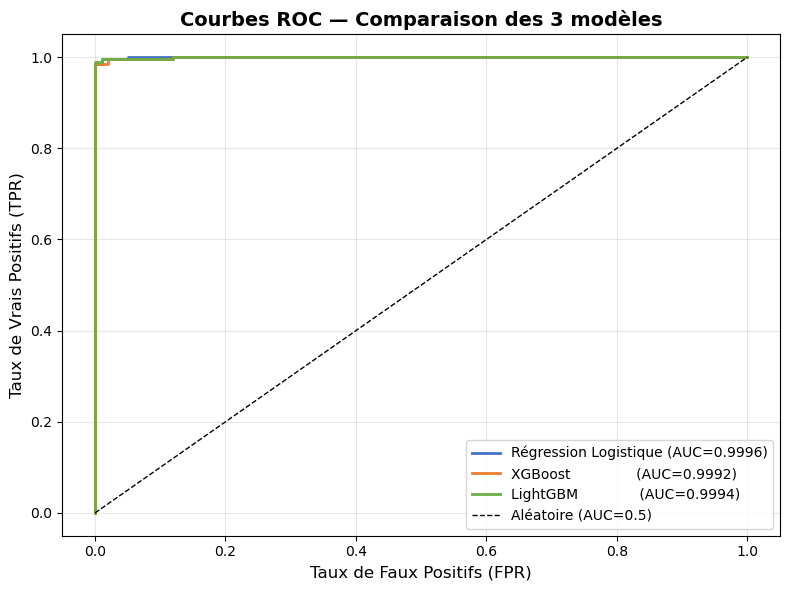

In [24]:
# 4.3 Courbes ROC 
fig, ax = plt.subplots(figsize=(8, 6))

# Données de chaque modèle : (probabilités, label, couleur)
modeles_roc = [
    (y_proba_lr,   f"Régression Logistique (AUC={auc_lr:.4f})",  "#4472C4"),
    (y_proba_xgb,  f"XGBoost               (AUC={auc_xgb:.4f})", "#ED7D31"),
    (y_proba_lgbm, f"LightGBM              (AUC={auc_lgbm:.4f})","#70AD47"),
]

for y_proba, label, couleur in modeles_roc:
    # roc_curve() calcule les points (FPR, TPR) pour chaque seuil
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax.plot(fpr, tpr, label=label, color=couleur, linewidth=2)

# Ligne de référence : modèle aléatoire
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Aléatoire (AUC=0.5)")

ax.set_xlabel("Taux de Faux Positifs (FPR)", fontsize=12)
ax.set_ylabel("Taux de Vrais Positifs (TPR)", fontsize=12)
ax.set_title("Courbes ROC — Comparaison des 3 modèles",
             fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show() 

In [25]:
#  4.4 Conclusion : quel est le meilleur modèle ? 

scores_auc = {
    "Régression Logistique": auc_lr,
    "XGBoost":               auc_xgb,
    "LightGBM":              auc_lgbm
}

# On cherche le nom du modèle avec le score AUC le plus élevé
meilleur_nom = max(scores_auc, key=scores_auc.get)
meilleur_auc = scores_auc[meilleur_nom]

print("=" * 50)
print("  CONCLUSION — MEILLEUR MODÈLE")
print("=" * 50)
for nom, auc in scores_auc.items():
    marqueur = "  <-- MEILLEUR" if nom == meilleur_nom else ""
    print(f"  {nom:<25} AUC = {auc:.4f}{marqueur}")
print("=" * 50)
print(f"\n  Le meilleur modèle est : {meilleur_nom}")
print(f"  AUC-ROC                : {meilleur_auc:.4f}")
print("\n  Ce modèle sera sauvegardé à l'étape 5.") 

  CONCLUSION — MEILLEUR MODÈLE
  Régression Logistique     AUC = 0.9996  <-- MEILLEUR
  XGBoost                   AUC = 0.9992
  LightGBM                  AUC = 0.9994

  Le meilleur modèle est : Régression Logistique
  AUC-ROC                : 0.9996

  Ce modèle sera sauvegardé à l'étape 5.


In [26]:
#  5.1 Création du dossier models
os.makedirs(MODELS_DIR, exist_ok=True)

print(f"Dossier models/ prêt : {MODELS_DIR}") 

Dossier models/ prêt : C:\Users\HP\Desktop\fake-bill-detector\models


In [27]:
# 5.2 Sauvegarde du meilleur modèle 
catalogue_modeles = {
    "Régression Logistique": modele_lr,
    "XGBoost":               modele_xgb,
    "LightGBM":              modele_lgbm
}

# On récupère l'objet du meilleur modèle trouvé à l'étape 4
meilleur_modele = catalogue_modeles[meilleur_nom]

# Chemin complet du fichier de sauvegarde  Le nom du fichier est construit automatiquement à partir du nom du modèle
nom_fichier  = meilleur_nom.lower().replace(" ", "_") + ".pkl"
chemin_modele = os.path.join(MODELS_DIR, nom_fichier)

# joblib.dump() sérialise l'objet Python et l'écrit sur le disque Le format .pkl (pickle) est le standard pour sauvegarder des modèles sklearn
joblib.dump(meilleur_modele, chemin_modele)

print(f"Modèle sauvegardé : {chemin_modele}") 

Modèle sauvegardé : C:\Users\HP\Desktop\fake-bill-detector\models\régression_logistique.pkl


In [28]:
 # 5.3 Sauvegarde du scaler 

chemin_scaler = os.path.join(MODELS_DIR, "scaler.pkl")
joblib.dump(scaler, chemin_scaler)

print(f"Scaler sauvegardé  : {chemin_scaler}") 

Scaler sauvegardé  : C:\Users\HP\Desktop\fake-bill-detector\models\scaler.pkl


In [29]:
#  5.4 Vérification — rechargement et test 
modele_charge = joblib.load(chemin_modele)
scaler_charge = joblib.load(chemin_scaler)

# On refait les prédictions avec le modèle rechargé
y_pred_verifie = modele_charge.predict(
    scaler_charge.transform(X_test)
)

# On compare avec les prédictions originales
predictions_identiques = (y_pred_verifie == y_pred_lr).all()

print("=" * 50)
print("  VÉRIFICATION DE LA SAUVEGARDE")
print("=" * 50)
print(f"  Modèle rechargé depuis  : {chemin_modele}")
print(f"  Scaler rechargé depuis  : {chemin_scaler}")
print(f"  Prédictions identiques  : {predictions_identiques} ✅")
print("=" * 50) 

  VÉRIFICATION DE LA SAUVEGARDE
  Modèle rechargé depuis  : C:\Users\HP\Desktop\fake-bill-detector\models\régression_logistique.pkl
  Scaler rechargé depuis  : C:\Users\HP\Desktop\fake-bill-detector\models\scaler.pkl
  Prédictions identiques  : True ✅
